In [1]:
from pathlib import Path
import subprocess

REPO_DIR = Path(
    "/kaggle/working/"
    "K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance"
)

REPO_URL = (
    "https://github.com/minhduong814/"
    "K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance.git"
)

if not (REPO_DIR / ".git").is_dir():
    subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_DIR)],
        check=True,
    )
else:
    subprocess.run(
        [
            "git", "-C", str(REPO_DIR),
            "pull", "--ff-only", "origin", "main",
        ],
        check=True,
    )

print("Repo ready:", REPO_DIR)

Cloning into '/kaggle/working/K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance'...


Repo ready: /kaggle/working/K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance


# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Notebook hoàn chỉnh cho Kaggle. Chạy tuần tự từng bước; các công tắc `RUN_*` ngăn một lần **Run All**
vô tình tiêu hết GPU hoặc mở tập test trước khi chốt cấu hình.

**Quy tắc quan trọng nhất:** chọn mọi thứ trên **val**; **test chỉ chạy một lần mỗi seed ở Bước 4**.

Bản đồ: Bước 0 (EDA, kiểm tra) → Bước 1 (backbone) → Bước 2 (công thức huấn luyện) → Bước 3 (suy luận)
→ Bước 4 (chung kết + `eval.py`) → Bước 5 (xlsx, biểu đồ, báo cáo).

## 0. Cài đặt môi trường

In [2]:
# Kaggle: bật Internet trong Settings trước khi chạy.
!pip -q install timm openpyxl thop

import json, os, platform, shutil, subprocess, sys
from pathlib import Path
import numpy as np, pandas as pd, torch, timm

STUDENT_REL = Path("submission/2A202602920_NguyenMinhDuong")
search_roots = [Path.cwd().resolve(), Path("/kaggle/working")]
candidates = []
for base in search_roots:
    if not base.exists():
        continue
    candidates.extend([base, *[p for p in base.iterdir() if p.is_dir()]])
REPO_DIR = next(
    (p for p in candidates if (p / "eval.py").is_file() and (p / STUDENT_REL / "code").is_dir()),
    None,
)
if REPO_DIR is None:
    raise FileNotFoundError(
        "Không tìm thấy repo. Hãy clone repo vào /kaggle/working rồi chạy lại cell này."
    )
REPO_DIR = REPO_DIR.resolve()
SUBMISSION_DIR = REPO_DIR / STUDENT_REL
CODE_DIR = SUBMISSION_DIR / "code"
DATA_DIR = (Path("/kaggle/working/deepweeds_data")
            if Path("/kaggle/working").exists() else REPO_DIR / "data")

for path in (str(CODE_DIR), str(REPO_DIR)):
    if path not in sys.path:
        sys.path.insert(0, path)
for folder in ("runs", "curves", "predictions", "eval_out"):
    (SUBMISSION_DIR / folder).mkdir(parents=True, exist_ok=True)

print("repo:", REPO_DIR)
print("data:", DATA_DIR)
print("python", platform.python_version(), "| torch", torch.__version__, "| timm", timm.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")

repo: /kaggle/working/K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance
data: /kaggle/working/deepweeds_data
python 3.13.15 | torch 2.11.0+cu128 | timm 1.0.29
GPU: Tesla T4


### Tải dữ liệu
Ảnh được tải từ Zenodo (~490 MB), kiểm tra MD5 rồi giải nén vào vùng làm việc của Kaggle.
Nhãn fold 0 được tải nguyên bản từ GitHub của tác giả. Cell tự tìm thư mục chứa đủ ảnh, không cần sửa path thủ công.

In [3]:
import hashlib, urllib.request, zipfile

DATA_DIR.mkdir(parents=True, exist_ok=True)
LABELS_DIR = DATA_DIR / "labels"
LABELS_DIR.mkdir(parents=True, exist_ok=True)
zip_path = DATA_DIR / "images.zip"
image_url = "https://zenodo.org/records/7939060/files/images.zip?download=1"
if not zip_path.exists():
    print("Đang tải images.zip...")
    urllib.request.urlretrieve(image_url, zip_path)

h = hashlib.md5()
with zip_path.open("rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", f"MD5 sai: {h.hexdigest()}"

extract_marker = DATA_DIR / ".images_extracted"
if not extract_marker.exists():
    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(DATA_DIR)
    extract_marker.touch()

base_url = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ("labels", "train_subset0", "val_subset0", "test_subset0"):
    target = LABELS_DIR / f"{name}.csv"
    if not target.exists():
        urllib.request.urlretrieve(f"{base_url}/{name}.csv", target)

jpgs = [*DATA_DIR.rglob("*.jpg"), *DATA_DIR.rglob("*.JPG")]
parent_counts = pd.Series([str(path.parent) for path in jpgs]).value_counts()
if parent_counts.empty:
    raise FileNotFoundError(f"Không tìm thấy ảnh JPG sau khi giải nén ở {DATA_DIR}")
IMAGES_DIR = Path(parent_counts.index[0])
print("images:", IMAGES_DIR, "| jpg:", parent_counts.iloc[0])
print("labels:", LABELS_DIR)

Đang tải images.zip...
images: /kaggle/working/deepweeds_data | jpg: 17509
labels: /kaggle/working/deepweeds_data/labels


In [4]:
# Toàn bộ output nhỏ nằm trong submission để có thể git add/commit sau phiên Kaggle.
COMMON = dict(
    images_dir=str(IMAGES_DIR),
    labels_dir=str(LABELS_DIR),
    out_dir=str(SUBMISSION_DIR / "runs"),
    pred_dir=str(SUBMISSION_DIR / "predictions"),
    num_workers=2,
)
print(COMMON)

{'images_dir': '/kaggle/working/deepweeds_data', 'labels_dir': '/kaggle/working/deepweeds_data/labels', 'out_dir': '/kaggle/working/K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance/submission/2A202602920_NguyenMinhDuong/runs', 'pred_dir': '/kaggle/working/K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance/submission/2A202602920_NguyenMinhDuong/predictions', 'num_workers': 2}


## Bước 0 — EDA và kiểm tra pipeline
Mục tiêu: hiểu dữ liệu, chạy các kiểm tra chia dữ liệu (README mục 2.1), kiểm tra pipeline trước khi chạy thật.

Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
train per class: {'Chinee Apple': 675, 'Lantana': 637, 'Parkinsonia': 618, 'Parthenium': 613, 'Prickly Acacia': 637, 'Rubber Vine': 605, 'Siam Weed': 644, 'Snake Weed': 609, 'Negatives': 5463}
val per class: {'Chinee Apple': 225, 'Lantana': 213, 'Parkinsonia': 206, 'Parthenium': 204, 'Prickly Acacia': 212, 'Rubber Vine': 202, 'Siam Weed': 215, 'Snake Weed': 203, 'Negatives': 1821}
test per class: {'Chinee Apple': 226, 'Lantana': 213, 'Parkinsonia': 207, 'Parthenium': 205, 'Prickly Acacia': 213, 'Rubber Vine': 202, 'Siam Weed': 215, 'Snake Weed': 204, 'Negatives': 1822}
Pairwise overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0} | union: 17509 | missing files: 0


,train,val,test
Chinee Apple,675,225,226
Lantana,637,213,213
Parkinsonia,618,206,207
Parthenium,613,204,205
Prickly Acacia,637,212,213
Rubber Vine,605,202,202
Siam Weed,644,215,215
Snake Weed,609,203,204
Negatives,5463,1821,1822


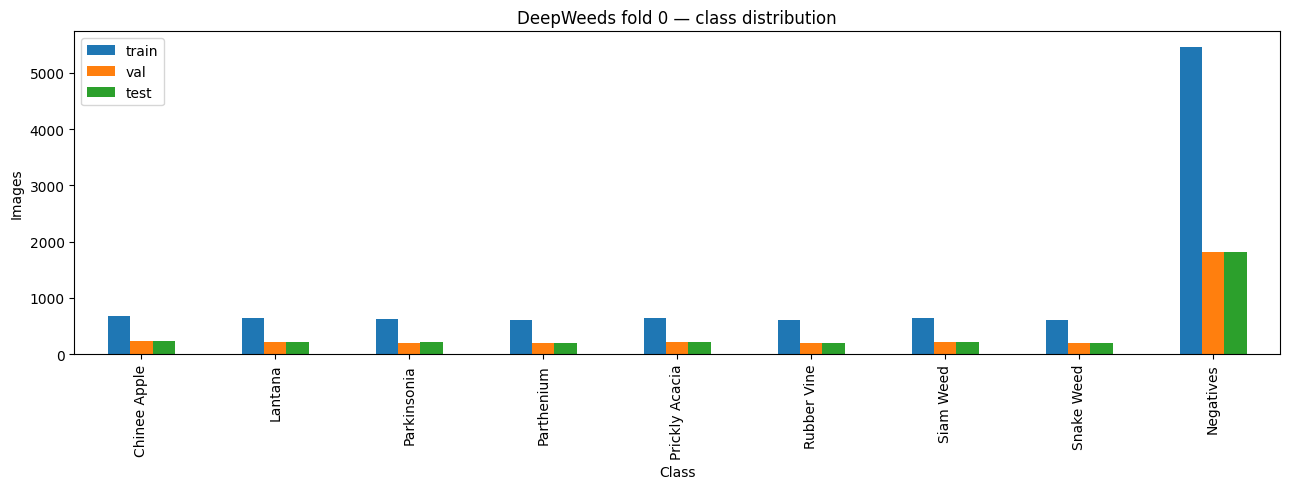

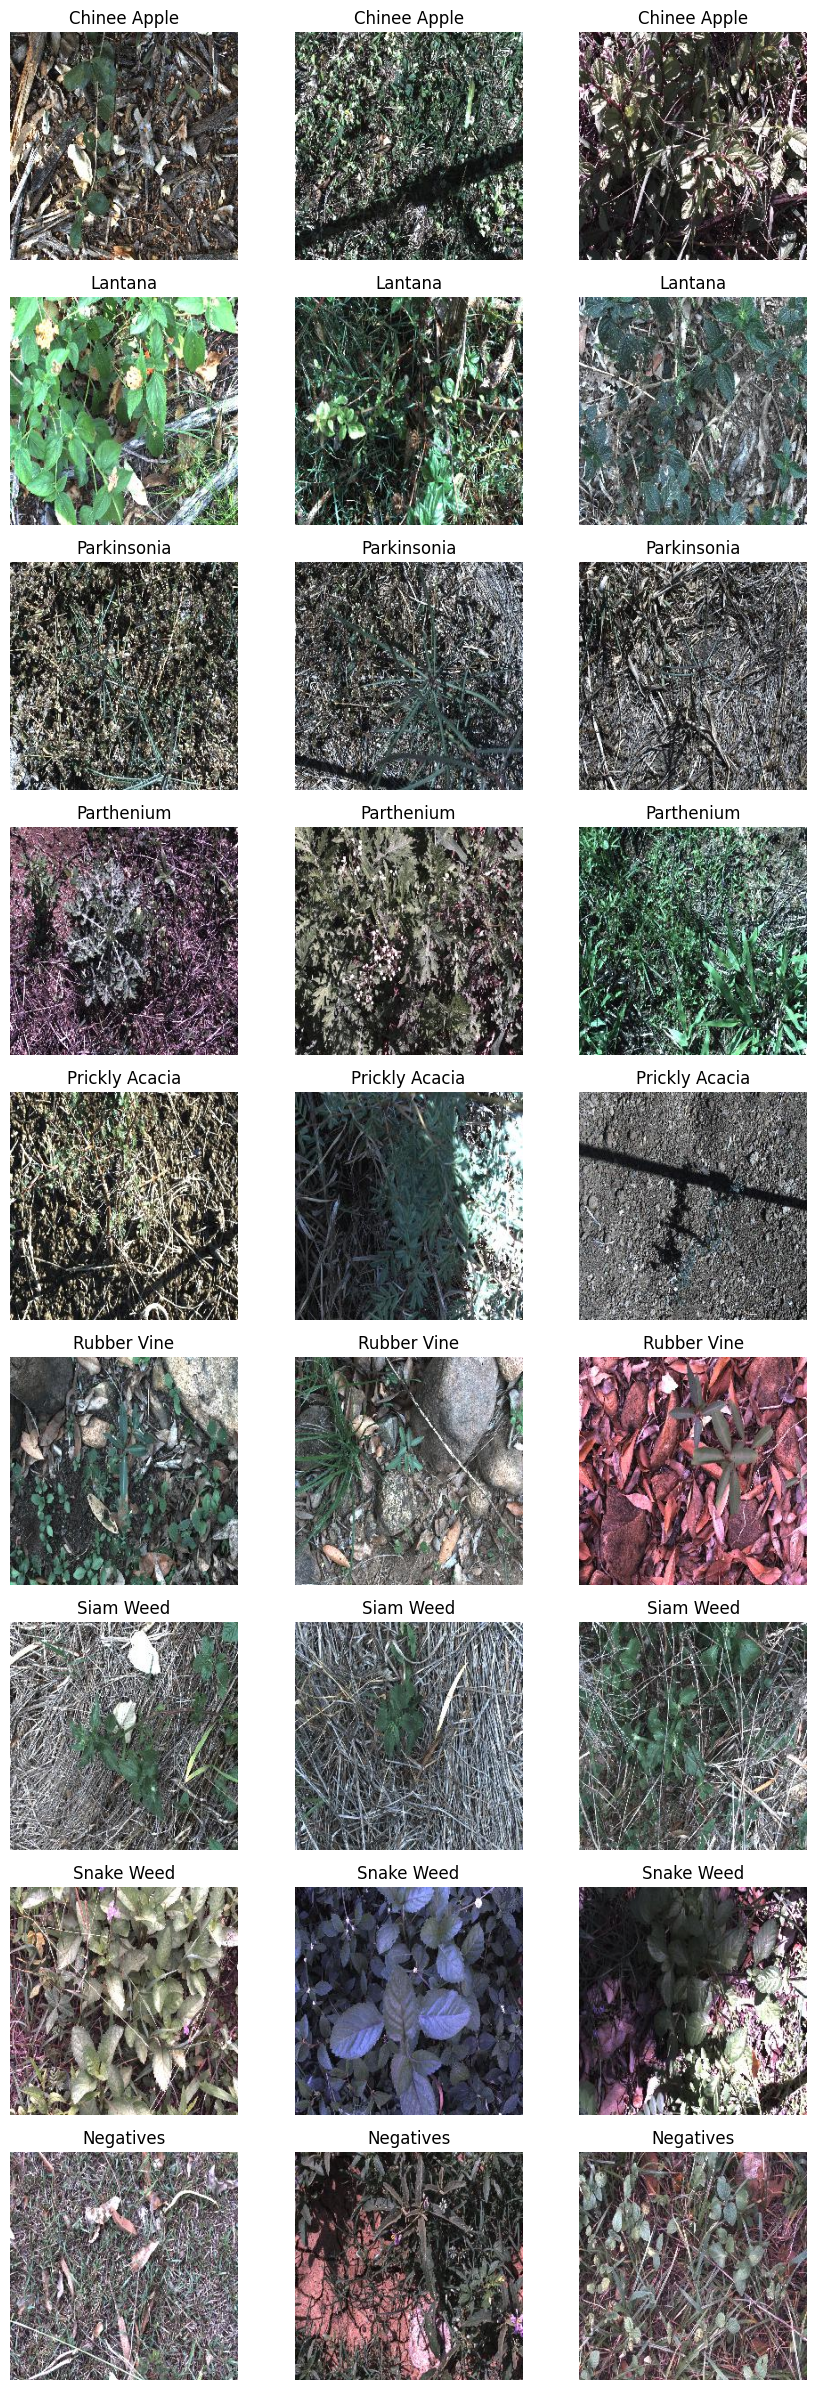

In [5]:
import importlib
import matplotlib.pyplot as plt
from PIL import Image
import dataset
dataset = importlib.reload(dataset)  # nhận code mới sau git pull mà không cần restart kernel

train_df, val_df, test_df = dataset.load_split(LABELS_DIR, fold=0)
split_report = dataset.check_split(train_df, val_df, test_df, IMAGES_DIR)

distribution = pd.DataFrame({
    split: frame["Label"].value_counts().reindex(range(dataset.NUM_CLASSES), fill_value=0)
    for split, frame in {"train": train_df, "val": val_df, "test": test_df}.items()
})
distribution.index = dataset.CLASS_NAMES
display(distribution)
ax = distribution.plot.bar(figsize=(13, 5), title="DeepWeeds fold 0 — class distribution")
ax.set(xlabel="Class", ylabel="Images")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(dataset.NUM_CLASSES, 3, figsize=(9, 24))
for label, class_name in enumerate(dataset.CLASS_NAMES):
    examples = train_df[train_df["Label"] == label].sample(3, random_state=0)
    for axis, (_, row) in zip(axes[label], examples.iterrows()):
        axis.imshow(Image.open(IMAGES_DIR / row["Filename"]).convert("RGB"))
        axis.set_title(class_name)
        axis.axis("off")
plt.tight_layout()
plt.show()

Initial CE = 2.3013; reference ln(9) = 2.1972


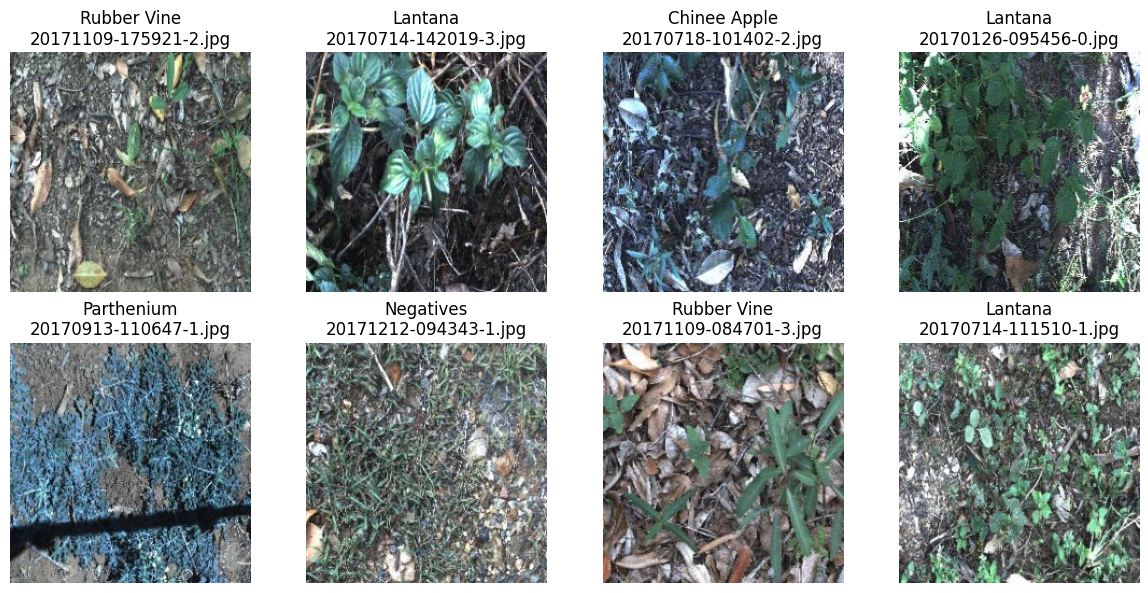

In [6]:
# Kiểm tra nhanh pipeline. Bật kiểm tra overfit sau khi đã xem ảnh augmentation.
import math
import torch.nn.functional as F
from dataset import IMAGENET_MEAN, IMAGENET_STD
from model import build_model
from train import set_seed

set_seed(0)
transform = dataset.build_transforms(train=True, img_size=224, aug="basic")
check_loader = dataset.make_loader(
    train_df.head(64), IMAGES_DIR, transform, batch_size=8,
    train=False, num_workers=0,
)
images, labels, names = next(iter(check_loader))
model_check = build_model("resnet50", pretrained=False, num_classes=9, init="scratch")
with torch.inference_mode():
    initial_loss = F.cross_entropy(model_check(images), labels).item()
print(f"Initial CE = {initial_loss:.4f}; reference ln(9) = {math.log(9):.4f}")
from losses import FocalLoss
probe_logits = torch.randn(16, 9)
probe_labels = torch.randint(0, 9, (16,))
assert torch.allclose(
    FocalLoss(gamma=0)(probe_logits, probe_labels),
    F.cross_entropy(probe_logits, probe_labels), atol=1e-6,
), "FocalLoss gamma=0 phải trùng CrossEntropyLoss"

mean = torch.tensor(IMAGENET_MEAN)[:, None, None]
std = torch.tensor(IMAGENET_STD)[:, None, None]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for axis, image, label, name in zip(axes.flat, images, labels, names):
    axis.imshow((image.cpu() * std + mean).permute(1, 2, 0).clamp(0, 1))
    axis.set_title(f"{dataset.CLASS_NAMES[int(label)]}\n{name}")
    axis.axis("off")
plt.tight_layout()
plt.show()

RUN_OVERFIT_CHECK = False
if RUN_OVERFIT_CHECK:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tiny_x, tiny_y = images[:8].to(device), labels[:8].to(device)
    tiny_model = build_model("resnet50", pretrained=False, num_classes=9, init="scratch").to(device)
    optimizer = torch.optim.Adam(tiny_model.parameters(), lr=3e-4)
    tiny_model.train()
    for step in range(300):
        optimizer.zero_grad(set_to_none=True)
        loss = F.cross_entropy(tiny_model(tiny_x), tiny_y)
        loss.backward()
        optimizer.step()
        if step % 50 == 0:
            print(step, float(loss))
    assert float(loss) < 0.1, "Chưa overfit được batch nhỏ; kiểm tra pipeline trước khi train thật."
del model_check
torch.cuda.empty_cache()

## Bước 1 — So sánh backbone (≥ 5)
Cùng công thức nền `T00` (GUIDE.md mục 1.4), cùng seed, mỗi backbone một lần chạy. Mã thí nghiệm `B01`, `B02`, ...

In [7]:
import model as model_module
import train as train_module
model_module = importlib.reload(model_module)
train_module = importlib.reload(train_module)
Config, run = train_module.Config, train_module.run

BACKBONES = [
    ("B01", "resnet50"),
    ("B02", "resnext50_32x4d"),
    ("B03", "convnext_tiny"),
    ("B04", "deit_small_patch16_224"),
    ("B05", "efficientnet_b0"),
]
RUN_BACKBONE_SWEEP = True  # bật sau khi pipeline checks đạt

backbone_results = []
if RUN_BACKBONE_SWEEP:
    for exp_id, backbone in BACKBONES:
        backbone_results.append(run(Config(
            exp_id=exp_id, backbone=backbone, seed=0, **COMMON
        )))
else:
    for path in (SUBMISSION_DIR / "runs").glob("B*/seed*/summary.json"):
        backbone_results.append(json.loads(path.read_text(encoding="utf-8")))

backbones_df = pd.DataFrame(backbone_results)
if not backbones_df.empty:
    backbones_df = backbones_df.sort_values("val_macro_f1", ascending=False)
display(backbones_df)
SELECTED_BACKBONE = (backbones_df.iloc[0]["backbone"]
                     if not backbones_df.empty else "resnet50")
print("Backbone dùng cho ablation (chỉ chốt theo val):", SELECTED_BACKBONE)

Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
train per class: {'Chinee Apple': 675, 'Lantana': 637, 'Parkinsonia': 618, 'Parthenium': 613, 'Prickly Acacia': 637, 'Rubber Vine': 605, 'Siam Weed': 644, 'Snake Weed': 609, 'Negatives': 5463}
val per class: {'Chinee Apple': 225, 'Lantana': 213, 'Parkinsonia': 206, 'Parthenium': 204, 'Prickly Acacia': 212, 'Rubber Vine': 202, 'Siam Weed': 215, 'Snake Weed': 203, 'Negatives': 1821}
test per class: {'Chinee Apple': 226, 'Lantana': 213, 'Parkinsonia': 207, 'Parthenium': 205, 'Prickly Acacia': 213, 'Rubber Vine': 202, 'Siam Weed': 215, 'Snake Weed': 204, 'Negatives': 1822}
Pairwise overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0} | union: 17509 | missing files: 0


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

[B01 seed=0] 01/12 loss=1.6284/1.2266 val_f1=0.2413 val_top1=0.5718
[B01 seed=0] 02/12 loss=0.8929/0.7640 val_f1=0.5861 val_top1=0.7224
[B01 seed=0] 03/12 loss=0.5895/0.6210 val_f1=0.6888 val_top1=0.7841
[B01 seed=0] 04/12 loss=0.4616/0.5638 val_f1=0.7287 val_top1=0.8086
[B01 seed=0] 05/12 loss=0.3718/0.5125 val_f1=0.7609 val_top1=0.8292
[B01 seed=0] 06/12 loss=0.3370/0.4844 val_f1=0.7755 val_top1=0.8380
[B01 seed=0] 07/12 loss=0.2991/0.4673 val_f1=0.7864 val_top1=0.8455
[B01 seed=0] 08/12 loss=0.2688/0.4687 val_f1=0.7876 val_top1=0.8463
[B01 seed=0] 09/12 loss=0.2651/0.4536 val_f1=0.7985 val_top1=0.8543
[B01 seed=0] 10/12 loss=0.2455/0.4512 val_f1=0.7954 val_top1=0.8518
[B01 seed=0] 11/12 loss=0.2544/0.4464 val_f1=0.7964 val_top1=0.8518
[B01 seed=0] 12/12 loss=0.2415/0.4339 val_f1=0.8024 val_top1=0.8558
Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
train per class: {'Chinee Apple': 675, 'Lantana': 637, 'Parkinsonia': 618, 'Parthenium': 613, 'Prickly Acacia': 637, 'Rubber Vi

model.safetensors: reconstructing file:   0%|          |  0.00B /  100MB            

...

model.safetensors: downloading bytes:           |  0.00B            

/kaggle/working/K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance/submission/2A202602920_NguyenMinhDuong/code/train.py:185: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[B05 seed=0] 01/12 loss=2.0669/1.2729 val_f1=0.4725 val_top1=0.5933
[B05 seed=0] 02/12 loss=0.6625/0.8793 val_f1=0.6227 val_top1=0.7232
[B05 seed=0] 03/12 loss=0.4062/0.7272 val_f1=0.6857 val_top1=0.7746
[B05 seed=0] 04/12 loss=0.2746/0.6533 val_f1=0.7190 val_top1=0.7901
[B05 seed=0] 05/12 loss=0.2052/0.5954 val_f1=0.7406 val_top1=0.8118
[B05 seed=0] 06/12 loss=0.1608/0.5570 val_f1=0.7601 val_top1=0.8266
[B05 seed=0] 07/12 loss=0.1242/0.4978 val_f1=0.7878 val_top1=0.8438
[B05 seed=0] 08/12 loss=0.1040/0.4921 val_f1=0.7953 val_top1=0.8486
[B05 seed=0] 09/12 loss=0.0889/0.4829 val_f1=0.7970 val_top1=0.8515
[B05 seed=0] 10/12 loss=0.0773/0.4766 val_f1=0.8028 val_top1=0.8555
[B05 seed=0] 11/12 loss=0.0851/0.4745 val_f1=0.8017 val_top1=0.8543
[B05 seed=0] 12/12 loss=0.0744/0.4599 val_f1=0.8101 val_top1=0.8575


,exp_id,seed,backbone,weight_tag,best_epoch,val_macro_f1,val_top1,val_ece,params_m,gmacs,seconds_per_epoch,curve,test_macro_f1,test_top1,test_ece
2,B03,0,convnext_tiny,timm/convnext_tiny.in12k_ft_in1k,12,0.965747,0.973436,0.018920,27.827049,4.454809,57.198310,curves/B03_convnext_tiny_seed0.png,None,None,None
3,B04,0,deit_small_patch16_224,timm/deit_small_patch16_224.fb_in1k,10,0.946524,0.960583,0.019555,21.669129,4.240838,38.357429,curves/B04_deit_small_patch16_224_seed0.png,None,None,None
1,B02,0,resnext50_32x4d,timm/resnext50_32x4d.a1h_in1k,12,0.856016,0.888032,0.035505,22.998345,4.286155,64.025478,curves/B02_resnext50_32x4d_seed0.png,None,None,None
4,B05,0,efficientnet_b0,timm/efficientnet_b0.ra_in1k,12,0.810140,0.857469,0.049109,4.019077,0.384610,33.271056,curves/B05_efficientnet_b0_seed0.png,None,None,None
0,B01,0,resnet50,timm/resnet50.a1_in1k,12,0.802369,0.855755,0.025870,23.526473,4.131713,48.101602,curves/B01_resnet50_seed0.png,None,None,None


Backbone dùng cho ablation (chỉ chốt theo val): convnext_tiny


## Bước 2 — Công thức huấn luyện (≥ 3 trục)
Mỗi lần chạy chỉ khác `T00` **một yếu tố**. Mã `T01`, `T02`, ... Ghi rõ khác ở điểm nào.

In [8]:
# Bốn trục A/B/C/F và một cấu hình kết hợp. Mỗi T01..T10 chỉ đổi một yếu tố so với T00.
TRAINING_EXPERIMENTS = [
    ("T00", {}),
    ("T01", {"init": "scratch"}),                         # A: initialization
    ("T02", {"init": "frozen"}),                          # A
    ("T03", {"aug": "color"}),                            # B: augmentation
    ("T04", {"aug": "randaug"}),                          # B
    ("T05", {"mix": "cutmix", "mix_alpha": 1.0}),         # B
    ("T06", {"loss": "ls", "label_smoothing": 0.1}),      # C: loss
    ("T07", {"loss": "focal", "focal_gamma": 2.0}),       # C
    ("T08", {"loss": "ce_weighted", "class_weight_beta": 0.0}),  # C
    ("T09", {"sampler": "balanced"}),                     # D: sampling
    ("T10", {"ema_decay": 0.999}),                        # F: regularization
    ("T11", {"mix": "cutmix", "loss": "ls",
             "label_smoothing": 0.1, "ema_decay": 0.999}), # combination
]
RUN_TRAINING_ABLATIONS = True

training_results = []
if RUN_TRAINING_ABLATIONS:
    for exp_id, changes in TRAINING_EXPERIMENTS:
        training_results.append(run(Config(
            exp_id=exp_id, backbone=SELECTED_BACKBONE, seed=0,
            **COMMON, **changes
        )))
else:
    for path in (SUBMISSION_DIR / "runs").glob("T*/seed*/summary.json"):
        training_results.append(json.loads(path.read_text(encoding="utf-8")))

training_df = pd.DataFrame(training_results)
if not training_df.empty:
    baseline = training_df.loc[training_df["exp_id"] == "T00", "val_macro_f1"]
    training_df["delta_vs_T00"] = (
        training_df["val_macro_f1"] - baseline.iloc[0] if len(baseline) else np.nan
    )
    training_df = training_df.sort_values("val_macro_f1", ascending=False)
display(training_df)
BEST_TRAIN_EXP = (training_df.iloc[0]["exp_id"] if not training_df.empty else "T11")
print("Recipe ứng viên (phải chốt theo val):", BEST_TRAIN_EXP)

Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
train per class: {'Chinee Apple': 675, 'Lantana': 637, 'Parkinsonia': 618, 'Parthenium': 613, 'Prickly Acacia': 637, 'Rubber Vine': 605, 'Siam Weed': 644, 'Snake Weed': 609, 'Negatives': 5463}
val per class: {'Chinee Apple': 225, 'Lantana': 213, 'Parkinsonia': 206, 'Parthenium': 204, 'Prickly Acacia': 212, 'Rubber Vine': 202, 'Siam Weed': 215, 'Snake Weed': 203, 'Negatives': 1821}
test per class: {'Chinee Apple': 226, 'Lantana': 213, 'Parkinsonia': 207, 'Parthenium': 205, 'Prickly Acacia': 213, 'Rubber Vine': 202, 'Siam Weed': 215, 'Snake Weed': 204, 'Negatives': 1822}
Pairwise overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0} | union: 17509 | missing files: 0


/kaggle/working/K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance/submission/2A202602920_NguyenMinhDuong/code/train.py:185: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T00 seed=0] 01/12 loss=0.6663/0.3894 val_f1=0.8300 val_top1=0.8783
[T00 seed=0] 02/12 loss=0.2311/0.2352 val_f1=0.9016 val_top1=0.9280
[T00 seed=0] 03/12 loss=0.1277/0.1796 val_f1=0.9377 val_top1=0.9492
[T00 seed=0] 04/12 loss=0.0767/0.1451 val_f1=0.9447 val_top1=0.9592
[T00 seed=0] 05/12 loss=0.0634/0.1584 val_f1=0.9404 val_top1=0.9546
[T00 seed=0] 06/12 loss=0.0364/0.1598 val_f1=0.9382 val_top1=0.9540
[T00 seed=0] 07/12 loss=0.0216/0.1237 val_f1=0.9585 val_top1=0.9674
[T00 seed=0] 08/12 loss=0.0095/0.1409 val_f1=0.9583 val_top1=0.9666
[T00 seed=0] 09/12 loss=0.0048/0.1389 val_f1=0.9597 val_top1=0.9677
[T00 seed=0] 10/12 loss=0.0022/0.1279 val_f1=0.9627 val_top1=0.9709
[T00 seed=0] 11/12 loss=0.0010/0.1252 val_f1=0.9649 val_top1=0.9729
[T00 seed=0] 12/12 loss=0.0016/0.1247 val_f1=0.9657 val_top1=0.9734
Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
train per class: {'Chinee Apple': 675, 'Lantana': 637, 'Parkinsonia': 618, 'Parthenium': 613, 'Prickly Acacia': 637, 'Rubber Vi

/kaggle/working/K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance/submission/2A202602920_NguyenMinhDuong/code/train.py:185: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T01 seed=0] 01/12 loss=1.6797/1.5764 val_f1=0.1178 val_top1=0.5230
[T01 seed=0] 02/12 loss=1.5706/1.5833 val_f1=0.1259 val_top1=0.5230
[T01 seed=0] 03/12 loss=1.5107/1.4441 val_f1=0.1918 val_top1=0.5321
[T01 seed=0] 04/12 loss=1.4698/1.4197 val_f1=0.1560 val_top1=0.5338
[T01 seed=0] 05/12 loss=1.3962/1.3181 val_f1=0.2072 val_top1=0.5536
[T01 seed=0] 06/12 loss=1.3343/1.3295 val_f1=0.2848 val_top1=0.5438
[T01 seed=0] 07/12 loss=1.2778/1.4580 val_f1=0.2476 val_top1=0.4999
[T01 seed=0] 08/12 loss=1.2419/1.3683 val_f1=0.3204 val_top1=0.5333
[T01 seed=0] 09/12 loss=1.2148/1.3755 val_f1=0.2906 val_top1=0.5301
[T01 seed=0] 10/12 loss=1.1862/1.4164 val_f1=0.2969 val_top1=0.5144
[T01 seed=0] 11/12 loss=1.1773/1.4203 val_f1=0.3151 val_top1=0.5170
[T01 seed=0] 12/12 loss=1.1684/1.3659 val_f1=0.3215 val_top1=0.5316
Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
train per class: {'Chinee Apple': 675, 'Lantana': 637, 'Parkinsonia': 618, 'Parthenium': 613, 'Prickly Acacia': 637, 'Rubber Vi

...

[T10 seed=0] 01/12 loss=0.6663/1.7358 val_f1=0.2082 val_top1=0.4333
[T10 seed=0] 02/12 loss=0.2311/1.0214 val_f1=0.5072 val_top1=0.6918
[T10 seed=0] 03/12 loss=0.1277/0.5740 val_f1=0.7647 val_top1=0.8258
[T10 seed=0] 04/12 loss=0.0767/0.3405 val_f1=0.8733 val_top1=0.8972
[T10 seed=0] 05/12 loss=0.0634/0.2175 val_f1=0.9174 val_top1=0.9312
[T10 seed=0] 06/12 loss=0.0364/0.1565 val_f1=0.9388 val_top1=0.9492
[T10 seed=0] 07/12 loss=0.0216/0.1263 val_f1=0.9512 val_top1=0.9594
[T10 seed=0] 08/12 loss=0.0095/0.1107 val_f1=0.9584 val_top1=0.9657
[T10 seed=0] 09/12 loss=0.0048/0.1038 val_f1=0.9626 val_top1=0.9694
[T10 seed=0] 10/12 loss=0.0022/0.1016 val_f1=0.9630 val_top1=0.9700
[T10 seed=0] 11/12 loss=0.0010/0.1017 val_f1=0.9635 val_top1=0.9709
[T10 seed=0] 12/12 loss=0.0016/0.1031 val_f1=0.9632 val_top1=0.9712
Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
train per class: {'Chinee Apple': 675, 'Lantana': 637, 'Parkinsonia': 618, 'Parthenium': 613, 'Prickly Acacia': 637, 'Rubber Vi

/kaggle/working/K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance/submission/2A202602920_NguyenMinhDuong/code/train.py:185: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T11 seed=0] 01/12 loss=1.3296/1.8719 val_f1=0.1770 val_top1=0.4185
[T11 seed=0] 02/12 loss=1.0029/1.3347 val_f1=0.4738 val_top1=0.6692
[T11 seed=0] 03/12 loss=0.9631/0.9782 val_f1=0.7508 val_top1=0.8115
[T11 seed=0] 04/12 loss=0.9234/0.7852 val_f1=0.8638 val_top1=0.8863
[T11 seed=0] 05/12 loss=0.8781/0.6789 val_f1=0.9122 val_top1=0.9243
[T11 seed=0] 06/12 loss=0.8640/0.6210 val_f1=0.9342 val_top1=0.9443
[T11 seed=0] 07/12 loss=0.8457/0.5886 val_f1=0.9509 val_top1=0.9594
[T11 seed=0] 08/12 loss=0.8414/0.5703 val_f1=0.9599 val_top1=0.9674
[T11 seed=0] 09/12 loss=0.8344/0.5586 val_f1=0.9655 val_top1=0.9729
[T11 seed=0] 10/12 loss=0.8265/0.5514 val_f1=0.9672 val_top1=0.9749
[T11 seed=0] 11/12 loss=0.8269/0.5469 val_f1=0.9686 val_top1=0.9760
[T11 seed=0] 12/12 loss=0.8186/0.5436 val_f1=0.9695 val_top1=0.9766


,exp_id,seed,backbone,weight_tag,best_epoch,val_macro_f1,val_top1,val_ece,params_m,gmacs,seconds_per_epoch,curve,test_macro_f1,test_top1,test_ece,delta_vs_T00
5,T05,0,convnext_tiny,timm/convnext_tiny.in12k_ft_in1k,12,0.974313,0.980291,0.005721,27.827049,4.454809,56.462278,curves/T05_convnext_tiny_seed0.png,None,None,None,0.008566
11,T11,0,convnext_tiny,timm/convnext_tiny.in12k_ft_in1k,12,0.969513,0.976578,0.088945,27.827049,4.454809,57.201032,curves/T11_convnext_tiny_seed0.png,None,None,None,0.003766
8,T08,0,convnext_tiny,timm/convnext_tiny.in12k_ft_in1k,10,0.967137,0.974864,0.012294,27.827049,4.454809,55.665935,curves/T08_convnext_tiny_seed0.png,None,None,None,0.001391
9,T09,0,convnext_tiny,timm/convnext_tiny.in12k_ft_in1k,12,0.966761,0.972865,0.014773,27.827049,4.454809,60.818409,curves/T09_convnext_tiny_seed0.png,None,None,None,0.001014
0,T00,0,convnext_tiny,timm/convnext_tiny.in12k_ft_in1k,12,0.965747,0.973436,0.018920,27.827049,4.454809,55.679190,curves/T00_convnext_tiny_seed0.png,None,None,None,0.000000
4,T04,0,convnext_tiny,timm/convnext_tiny.in12k_ft_in1k,12,0.963803,0.970580,0.018207,27.827049,4.454809,55.981760,curves/T04_convnext_tiny_seed0.png,None,None,None,-0.001944
6,T06,0,convnext_tiny,timm/convnext_tiny.in12k_ft_in1k,11,0.963751,0.972294,0.084536,27.827049,4.454809,56.233473,curves/T06_convnext_tiny_seed0.png,None,None,None,-0.001996
10,T10,0,convnext_tiny,timm/convnext_tiny.in12k_ft_in1k,11,0.963514,0.970865,0.012620,27.827049,4.454809,56.091356,curves/T10_convnext_tiny_seed0.png,None,None,None,-0.002233
7,T07,0,convnext_tiny,timm/convnext_tiny.in12k_ft_in1k,9,0.958772,0.969152,0.010037,27.827049,4.454809,54.785238,curves/T07_convnext_tiny_seed0.png,None,None,None,-0.006975
3,T03,0,convnext_tiny,timm/convnext_tiny.in12k_ft_in1k,11,0.958754,0.966867,0.017938,27.827049,4.454809,57.439397,curves/T03_convnext_tiny_seed0.png,None,None,None,-0.006993


Recipe ứng viên (phải chốt theo val): T05


## Bước 3 — Suy luận (≥ 4 phương pháp) và độ trễ
Làm trên **val**. Không huấn luyện lại. Mã `I00` (1 view, mốc), `I01`, ...

In [9]:
# Bật sau khi đã chọn BEST_TRAIN_EXP. Kết quả chỉ dùng validation.
from eval import compute_metrics
from inference import (
    aggregate_views, apply_temperature, fit_temperature, fuse_conv_bn,
    predict_logits, view_hflip,
)
from benchmark import latency_report, tta_latency
from model import build_model

RUN_INFERENCE_STUDY = True
inference_records, latency_records = [], []

def metric_row(exp_id, method, probs, y_true, k):
    m = compute_metrics(y_true, probs.argmax(1), probs)
    return dict(exp_id=exp_id, method=method, K=k, macro_f1_val=m["macro_f1"],
                top1_val=m["top1"], ece_val=m["ece"])

if RUN_INFERENCE_STUDY:
    summary_path = next((SUBMISSION_DIR / "runs" / BEST_TRAIN_EXP).glob("seed0/summary.json"))
    config_path = summary_path.parent / "config.json"
    cfg = Config(**json.loads(config_path.read_text(encoding="utf-8")))
    checkpoint = torch.load(summary_path.parent / "best.pt", map_location="cpu")
    inference_model = build_model(
        cfg.backbone, pretrained=False, num_classes=9,
        drop_rate=cfg.drop_rate, init="scratch",
    )
    inference_model.load_state_dict(checkpoint["model"])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    inference_model.to(device).eval()
    val_loader = dataset.make_loader(
        val_df, IMAGES_DIR, dataset.build_transforms(False, cfg.img_size, cfg.aug),
        cfg.batch_size, train=False, num_workers=cfg.num_workers,
    )

    names, y_val, logits_1 = predict_logits(inference_model, val_loader, device)
    names_flip, y_flip, logits_flip = predict_logits(
        inference_model, val_loader, device, view=view_hflip
    )
    assert names == names_flip and np.array_equal(y_val, y_flip)
    probs_1 = aggregate_views([logits_1], "prob")
    probs_flip_prob = aggregate_views([logits_1, logits_flip], "prob")
    probs_flip_logit = aggregate_views([logits_1, logits_flip], "logit")
    inference_records.extend([
        metric_row("I00", "1-view", probs_1, y_val, 1),
        metric_row("I01", "hflip, probability mean", probs_flip_prob, y_val, 2),
        metric_row("I02", "hflip, logit mean", probs_flip_logit, y_val, 2),
    ])

    _, y_vflip, logits_vflip = predict_logits(
        inference_model, val_loader, device, view=lambda x: torch.flip(x, dims=(-2,))
    )
    _, y_hvflip, logits_hvflip = predict_logits(
        inference_model, val_loader, device, view=lambda x: torch.flip(x, dims=(-2, -1))
    )
    assert np.array_equal(y_val, y_vflip) and np.array_equal(y_val, y_hvflip)
    inference_records.append(metric_row(
        "I03", "4 flips, probability mean",
        aggregate_views([logits_1, logits_flip, logits_vflip, logits_hvflip], "prob"),
        y_val, 4,
    ))

    scale_logits, supported_sizes = [], []
    for size in (224, 256, 288):
        try:
            _, labels_scale, logits_scale = predict_logits(
                inference_model, val_loader, device,
                view=lambda x, s=size: torch.nn.functional.interpolate(
                    x, size=(s, s), mode="bilinear", align_corners=False, antialias=True
                ),
            )
        except (RuntimeError, AssertionError) as exc:
            print(f"Bỏ qua scale {size} cho {cfg.backbone}: {exc}")
            continue
        assert np.array_equal(y_val, labels_scale)
        scale_logits.append(logits_scale)
        supported_sizes.append(size)
    if len(scale_logits) > 1:
        inference_records.append(metric_row(
            "I04", f"multi-scale {supported_sizes}",
            aggregate_views(scale_logits, "prob"), y_val, len(scale_logits)
        ))

    temperature = fit_temperature(logits_1, y_val)
    inference_records.append(metric_row(
        "I07", f"temperature T={temperature:.4f}",
        apply_temperature(logits_1, temperature), y_val, 1
    ))

    fused_model = fuse_conv_bn(inference_model).to(device)
    _, y_fused, logits_fused = predict_logits(fused_model, val_loader, device)
    inference_records.append(metric_row(
        "I08", "Conv-BN fusion", aggregate_views([logits_fused]), y_fused, 1
    ))

    for batch in (1, 32):
        latency_records.append({
            "configuration": "I00", "fused_bn": False,
            **latency_report(inference_model, batch, cfg.img_size, dtype="amp",
                             device=str(device), warmup=10, iters=100),
        })
    latency_records.append({
        "configuration": "I01", "fused_bn": False,
        **tta_latency(inference_model, 2, batch_size=1, img_size=cfg.img_size,
                      dtype="amp", device=str(device), warmup=10, iters=100),
    })
    latency_records.append({
        "configuration": "I08", "fused_bn": True,
        **latency_report(fused_model, 1, cfg.img_size, dtype="amp",
                         device=str(device), warmup=10, iters=100),
    })
    pd.DataFrame(inference_records).to_csv(
        SUBMISSION_DIR / "runs/inference_results.csv", index=False
    )
    pd.DataFrame(latency_records).to_csv(
        SUBMISSION_DIR / "runs/latency_results.csv", index=False
    )

inference_df = (
    pd.DataFrame(inference_records) if inference_records
    else pd.read_csv(SUBMISSION_DIR / "runs/inference_results.csv")
    if (SUBMISSION_DIR / "runs/inference_results.csv").exists() else pd.DataFrame()
)
latency_df = (
    pd.DataFrame(latency_records) if latency_records
    else pd.read_csv(SUBMISSION_DIR / "runs/latency_results.csv")
    if (SUBMISSION_DIR / "runs/latency_results.csv").exists() else pd.DataFrame()
)
display(inference_df)
display(latency_df)

,exp_id,method,K,macro_f1_val,top1_val,ece_val
0,I00,1-view,1,0.974313,0.980291,0.005721
1,I01,"hflip, probability mean",2,0.976835,0.982291,0.005649
2,I02,"hflip, logit mean",2,0.976835,0.982291,0.005154
3,I03,"4 flips, probability mean",4,0.978826,0.983719,0.008973
4,I04,"multi-scale [224, 256, 288]",3,0.977478,0.982005,0.017272
5,I07,temperature T=0.9360,1,0.974313,0.980291,0.003444
6,I08,Conv-BN fusion,1,0.974313,0.980291,0.005721


,configuration,fused_bn,p50,p95,p99,mean,n,gpu,dtype,batch,img_size,images_per_s,torch,includes_preprocessing,k_views,single_view_p50,linear_expected_p50,relative_to_single,measured_over_linear
0,I00,False,7.953290,8.424766,9.119956,8.004503,100,Tesla T4,amp,1,224,125.734122,2.11.0+cu128,False,NaN,NaN,NaN,NaN,NaN
1,I00,False,55.378489,56.308466,56.745880,55.255819,100,Tesla T4,amp,32,224,577.841696,2.11.0+cu128,False,NaN,NaN,NaN,NaN,NaN
2,I01,False,15.738451,16.431968,17.670059,15.813279,100,Tesla T4,amp,1,224,63.538656,2.11.0+cu128,False,2.0,7.646098,15.292195,2.058364,1.029182
3,I08,True,7.877182,8.499150,9.534534,7.967164,100,Tesla T4,amp,1,224,126.948960,2.11.0+cu128,False,NaN,NaN,NaN,NaN,NaN


## Bước 4 — Chung kết: ≥ 3 seed, test đúng một lần mỗi seed
1. Chốt backbone, recipe và inference hoàn toàn bằng **val**.
2. Gõ chuỗi xác nhận trong cell dưới rồi chạy cấu hình cuối và mốc với cùng ba seed.
3. Không chạy lại cell sau khi đã xem test. Nếu phát hiện lỗi, ghi lại trong báo cáo.

In [10]:
# Chỉ cần đổi hai công tắc này sau khi đã chốt validation; recipe được lấy tự động.
RUN_FINAL_TEST = True
FINAL_TEST_CONFIRMATION = "LOCKED_FROM_VALIDATION"  # điền chính xác: LOCKED_FROM_VALIDATION

best_config_files = sorted(
    (SUBMISSION_DIR / "runs" / BEST_TRAIN_EXP).glob("seed*/config.json")
)
best_val_config = (
    json.loads(best_config_files[0].read_text(encoding="utf-8"))
    if best_config_files else None
)
recipe_fields = (
    "backbone", "init", "drop_rate", "img_size", "aug", "sampler", "mix", "mix_alpha",
    "loss", "label_smoothing", "focal_gamma", "class_weight_beta", "epochs", "batch_size",
    "lr_backbone", "lr_head", "weight_decay", "warmup_epochs", "ema_decay", "amp",
)
FINAL_RECIPE = (
    {key: best_val_config[key] for key in recipe_fields}
    if best_val_config is not None else None
)

# Temperature scaling chỉ được bật tự động nếu ECE validation giảm so với I00.
FINAL_USE_TEMPERATURE = False
if not inference_df.empty and {"I00", "I07"} <= set(inference_df["exp_id"]):
    ece_by_id = inference_df.set_index("exp_id")["ece_val"]
    FINAL_USE_TEMPERATURE = bool(ece_by_id["I07"] < ece_by_id["I00"])

print("Recipe khóa từ validation:", BEST_TRAIN_EXP, FINAL_RECIPE)
if FINAL_RECIPE is None:
    print("Chưa có recipe; chạy Bước 2 trước khi mở khóa test.")
print("Temperature scaling:", FINAL_USE_TEMPERATURE)

if RUN_FINAL_TEST:
    assert FINAL_TEST_CONFIRMATION == "LOCKED_FROM_VALIDATION"
    assert FINAL_RECIPE is not None, "Chưa có recipe thắng từ validation"
    from eval import save_predictions
    from inference import fit_temperature, apply_temperature

    for seed in (0, 1, 2):
        final_cfg = Config(
            exp_id="F01", seed=seed, save_test_predictions=True,
            **COMMON, **FINAL_RECIPE,
        )
        run(final_cfg)

        baseline_cfg = Config(
            exp_id="T00", backbone=FINAL_RECIPE["backbone"], seed=seed,
            save_test_predictions=True, **COMMON,
        )
        run(baseline_cfg)

        if FINAL_USE_TEMPERATURE:
            final_run_dir = Path(final_cfg.out_dir) / "F01" / f"seed{seed}"
            val_logits = np.load(final_run_dir / "val_logits.npy")
            test_logits = np.load(final_run_dir / "test_logits.npy")
            val_uncal = pd.read_csv(Path(final_cfg.pred_dir) / f"F01_seed{seed}_val.csv")
            test_uncal = pd.read_csv(Path(final_cfg.pred_dir) / f"F01_seed{seed}_test.csv")
            shutil.copy2(
                Path(final_cfg.pred_dir) / f"F01_seed{seed}_test.csv",
                Path(final_cfg.pred_dir) / f"F01uncal_seed{seed}_test.csv",
            )
            temperature = fit_temperature(val_logits, val_uncal["y_true"].to_numpy())
            save_predictions(
                Path(final_cfg.pred_dir) / f"F01_seed{seed}_val.csv",
                val_uncal["Filename"], val_uncal["y_true"],
                apply_temperature(val_logits, temperature),
            )
            save_predictions(
                Path(final_cfg.pred_dir) / f"F01_seed{seed}_test.csv",
                test_uncal["Filename"], test_uncal["y_true"],
                apply_temperature(test_logits, temperature),
            )
            print(f"seed={seed}: fitted T={temperature:.5f} on val")
else:
    print("Test đang khóa. Chỉ mở sau khi đã chốt mọi lựa chọn bằng validation.")

Recipe khóa từ validation: T05 {'backbone': 'convnext_tiny', 'init': 'finetune', 'drop_rate': 0.0, 'img_size': 224, 'aug': 'basic', 'sampler': None, 'mix': 'cutmix', 'mix_alpha': 1.0, 'loss': 'ce', 'label_smoothing': 0.0, 'focal_gamma': 2.0, 'class_weight_beta': None, 'epochs': 12, 'batch_size': 64, 'lr_backbone': 0.0001, 'lr_head': 0.001, 'weight_decay': 0.05, 'warmup_epochs': 1.0, 'ema_decay': None, 'amp': True}
Temperature scaling: True
Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
train per class: {'Chinee Apple': 675, 'Lantana': 637, 'Parkinsonia': 618, 'Parthenium': 613, 'Prickly Acacia': 637, 'Rubber Vine': 605, 'Siam Weed': 644, 'Snake Weed': 609, 'Negatives': 5463}
val per class: {'Chinee Apple': 225, 'Lantana': 213, 'Parkinsonia': 206, 'Parthenium': 204, 'Prickly Acacia': 212, 'Rubber Vine': 202, 'Siam Weed': 215, 'Snake Weed': 203, 'Negatives': 1821}
test per class: {'Chinee Apple': 226, 'Lantana': 213, 'Parkinsonia': 207, 'Parthenium': 205, 'Prickly Acacia': 213,

/kaggle/working/K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance/submission/2A202602920_NguyenMinhDuong/code/train.py:185: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[F01 seed=0] 01/12 loss=1.1098/0.4065 val_f1=0.8349 val_top1=0.8698
[F01 seed=0] 02/12 loss=0.6991/0.2323 val_f1=0.9094 val_top1=0.9272
[F01 seed=0] 03/12 loss=0.6317/0.2001 val_f1=0.9221 val_top1=0.9403
[F01 seed=0] 04/12 loss=0.5751/0.1437 val_f1=0.9495 val_top1=0.9594
[F01 seed=0] 05/12 loss=0.5196/0.1064 val_f1=0.9598 val_top1=0.9689
[F01 seed=0] 06/12 loss=0.4911/0.1140 val_f1=0.9634 val_top1=0.9712
[F01 seed=0] 07/12 loss=0.4681/0.0954 val_f1=0.9684 val_top1=0.9757
[F01 seed=0] 08/12 loss=0.4565/0.0755 val_f1=0.9689 val_top1=0.9771
[F01 seed=0] 09/12 loss=0.4424/0.0746 val_f1=0.9721 val_top1=0.9803
[F01 seed=0] 10/12 loss=0.4311/0.0731 val_f1=0.9727 val_top1=0.9789
[F01 seed=0] 11/12 loss=0.4311/0.0699 val_f1=0.9738 val_top1=0.9803
[F01 seed=0] 12/12 loss=0.4200/0.0682 val_f1=0.9743 val_top1=0.9803
Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
train per class: {'Chinee Apple': 675, 'Lantana': 637, 'Parkinsonia': 618, 'Parthenium': 613, 'Prickly Acacia': 637, 'Rubber Vi

/kaggle/working/K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance/submission/2A202602920_NguyenMinhDuong/code/train.py:185: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[F01 seed=1] 01/12 loss=1.1894/0.3239 val_f1=0.8855 val_top1=0.9069
[F01 seed=1] 02/12 loss=0.7311/0.2272 val_f1=0.9112 val_top1=0.9317
[F01 seed=1] 03/12 loss=0.6429/0.1806 val_f1=0.9299 val_top1=0.9463
[F01 seed=1] 04/12 loss=0.5669/0.1556 val_f1=0.9449 val_top1=0.9549
[F01 seed=1] 05/12 loss=0.5362/0.1273 val_f1=0.9511 val_top1=0.9640
[F01 seed=1] 06/12 loss=0.5152/0.1115 val_f1=0.9576 val_top1=0.9677
[F01 seed=1] 07/12 loss=0.4765/0.0958 val_f1=0.9634 val_top1=0.9726
[F01 seed=1] 08/12 loss=0.4842/0.1151 val_f1=0.9533 val_top1=0.9629
[F01 seed=1] 09/12 loss=0.4446/0.0822 val_f1=0.9651 val_top1=0.9743
[F01 seed=1] 10/12 loss=0.4300/0.0822 val_f1=0.9675 val_top1=0.9749
[F01 seed=1] 11/12 loss=0.4201/0.0760 val_f1=0.9715 val_top1=0.9789
[F01 seed=1] 12/12 loss=0.4191/0.0728 val_f1=0.9714 val_top1=0.9786
Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
train per class: {'Chinee Apple': 675, 'Lantana': 637, 'Parkinsonia': 618, 'Parthenium': 613, 'Prickly Acacia': 637, 'Rubber Vi

...

[T00 seed=1] 01/12 loss=0.7263/0.3226 val_f1=0.8845 val_top1=0.9006
[T00 seed=1] 02/12 loss=0.2347/0.2285 val_f1=0.9076 val_top1=0.9277
[T00 seed=1] 03/12 loss=0.1312/0.1988 val_f1=0.9157 val_top1=0.9332
[T00 seed=1] 04/12 loss=0.0865/0.1678 val_f1=0.9367 val_top1=0.9483
[T00 seed=1] 05/12 loss=0.0578/0.1935 val_f1=0.9280 val_top1=0.9457
[T00 seed=1] 06/12 loss=0.0333/0.1592 val_f1=0.9431 val_top1=0.9577
[T00 seed=1] 07/12 loss=0.0166/0.1235 val_f1=0.9626 val_top1=0.9697
[T00 seed=1] 08/12 loss=0.0070/0.1197 val_f1=0.9628 val_top1=0.9703
[T00 seed=1] 09/12 loss=0.0027/0.1303 val_f1=0.9643 val_top1=0.9712
[T00 seed=1] 10/12 loss=0.0009/0.1186 val_f1=0.9692 val_top1=0.9754
[T00 seed=1] 11/12 loss=0.0007/0.1191 val_f1=0.9694 val_top1=0.9754
[T00 seed=1] 12/12 loss=0.0015/0.1193 val_f1=0.9689 val_top1=0.9751
seed=1: fitted T=0.95190 on val
Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
train per class: {'Chinee Apple': 675, 'Lantana': 637, 'Parkinsonia': 618, 'Parthenium': 613, '

/kaggle/working/K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance/submission/2A202602920_NguyenMinhDuong/code/train.py:185: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[F01 seed=2] 01/12 loss=1.1743/0.2724 val_f1=0.8957 val_top1=0.9177
[F01 seed=2] 02/12 loss=0.7190/0.2351 val_f1=0.9131 val_top1=0.9349
[F01 seed=2] 03/12 loss=0.6243/0.1659 val_f1=0.9368 val_top1=0.9494
[F01 seed=2] 04/12 loss=0.5602/0.1473 val_f1=0.9462 val_top1=0.9577
[F01 seed=2] 05/12 loss=0.5625/0.1128 val_f1=0.9622 val_top1=0.9703
[F01 seed=2] 06/12 loss=0.5062/0.1060 val_f1=0.9625 val_top1=0.9706
[F01 seed=2] 07/12 loss=0.4804/0.0989 val_f1=0.9614 val_top1=0.9697
[F01 seed=2] 08/12 loss=0.4559/0.0929 val_f1=0.9677 val_top1=0.9749
[F01 seed=2] 09/12 loss=0.4182/0.0785 val_f1=0.9728 val_top1=0.9789
[F01 seed=2] 10/12 loss=0.4247/0.0802 val_f1=0.9726 val_top1=0.9791
[F01 seed=2] 11/12 loss=0.4293/0.0797 val_f1=0.9720 val_top1=0.9786
[F01 seed=2] 12/12 loss=0.4394/0.0782 val_f1=0.9728 val_top1=0.9789
Split sizes: {'train': 10501, 'val': 3501, 'test': 3507}
train per class: {'Chinee Apple': 675, 'Lantana': 637, 'Parkinsonia': 618, 'Parthenium': 613, 'Prickly Acacia': 637, 'Rubber Vi

/kaggle/working/K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance/submission/2A202602920_NguyenMinhDuong/code/train.py:185: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T00 seed=2] 01/12 loss=0.6953/0.2962 val_f1=0.8698 val_top1=0.9017
[T00 seed=2] 02/12 loss=0.2341/0.3037 val_f1=0.8698 val_top1=0.9003
[T00 seed=2] 03/12 loss=0.1310/0.2144 val_f1=0.9095 val_top1=0.9309
[T00 seed=2] 04/12 loss=0.0858/0.2220 val_f1=0.9151 val_top1=0.9372
[T00 seed=2] 05/12 loss=0.0537/0.2044 val_f1=0.9184 val_top1=0.9386
[T00 seed=2] 06/12 loss=0.0429/0.1299 val_f1=0.9494 val_top1=0.9606
[T00 seed=2] 07/12 loss=0.0196/0.1253 val_f1=0.9560 val_top1=0.9666
[T00 seed=2] 08/12 loss=0.0090/0.1100 val_f1=0.9648 val_top1=0.9729
[T00 seed=2] 09/12 loss=0.0031/0.1155 val_f1=0.9668 val_top1=0.9740
[T00 seed=2] 10/12 loss=0.0014/0.0984 val_f1=0.9672 val_top1=0.9751
[T00 seed=2] 11/12 loss=0.0009/0.1025 val_f1=0.9651 val_top1=0.9734
[T00 seed=2] 12/12 loss=0.0005/0.1023 val_f1=0.9649 val_top1=0.9734
seed=2: fitted T=0.94897 on val


In [11]:
# Tính chỉ số đúng định nghĩa của lớp khi đủ prediction files.
pred_dir = SUBMISSION_DIR / "predictions"
score_jobs = [
    ("F01", str(pred_dir / "F01_seed*_test.csv")),
    ("T00", str(pred_dir / "T00_seed*_test.csv")),
]
for tag, pattern in score_jobs:
    if list(pred_dir.glob(f"{tag}_seed*_test.csv")):
        subprocess.run([
            sys.executable, str(REPO_DIR / "eval.py"), "score",
            "--pred", pattern,
            "--test-csv", str(LABELS_DIR / "test_subset0.csv"),
            "--labels", str(LABELS_DIR / "labels.csv"),
            "--tag", tag,
            "--out", str(SUBMISSION_DIR / "eval_out"),
        ], check=True)
    else:
        print("Bỏ qua score vì chưa có:", pattern)

### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9793 ± 0.0014 |
| macro-F1 | 0.9745 ± 0.0022 |
| balanced accuracy | 0.9781 ± 0.0019 |
| ECE (15 bin) | 0.0043 ± 0.0011 |
| NLL | 0.0695 ± 0.0026 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.972 ± 0.009 | 0.954 ± 0.007 | 0.963 ± 0.006 | 226 |
| Lantana | 0.958 ± 0.025 | 0.977 ± 0.005 | 0.967 ± 0.011 | 213 |
| Parkinsonia | 0.979 ± 0.003 | 0.987 ± 0.003 | 0.983 ± 0.000 | 207 |
| Parthenium | 0.990 ± 0.010 | 0.984 ± 0.007 | 0.987 ± 0.008 | 205 |
| Prickly acacia | 0.942 ± 0.013 | 0.989 ± 0.003 | 0.965 ± 0.007 | 213 |
| Rubber vine | 0.976 ± 0.005 | 0.987 ± 0.003 | 0.981 ± 0.001 | 202 |
| Siam weed | 0.971 ± 0.015 | 0.992 ± 0.007 | 0.982 ± 0.004 | 215 |
| Snake weed | 0.964 ± 0.010 | 0.953 ± 0.011 | 0.958 ± 0.000 | 204 |
| Negative | 0.989 ± 0.003 | 0.981 ± 0.001 | 0.985 ± 0.001 | 1822 |

Đã lưu kết quả vào /kaggle/working/K4-Track4-Day2-NguyenMinhDuong-2

In [12]:
# Tự chấm phần I sau lần test cuối.
if (list(pred_dir.glob("F01_seed*_test.csv"))
        and list(pred_dir.glob("T00_seed*_test.csv"))):
    command = [
        sys.executable, str(REPO_DIR / "eval.py"), "grade",
        "--final", str(pred_dir / "F01_seed*_test.csv"),
        "--baseline", str(pred_dir / "T00_seed*_test.csv"),
        "--test-csv", str(LABELS_DIR / "test_subset0.csv"),
        "--labels", str(LABELS_DIR / "labels.csv"),
        "--out", str(SUBMISSION_DIR / "eval_out"),
    ]
    if list(pred_dir.glob("F01uncal_seed*_test.csv")):
        command.extend(["--uncal", str(pred_dir / "F01uncal_seed*_test.csv")])
    if list(pred_dir.glob("F01_seed*_val.csv")):
        command.extend([
            "--final-val", str(pred_dir / "F01_seed*_val.csv"),
            "--val-csv", str(LABELS_DIR / "val_subset0.csv"),
        ])
    subprocess.run(command, check=True)
else:
    print("Chưa có đủ F01 và T00 test predictions; chưa chạy grade.")

## Tự chấm RUBRIC mục I (đề xuất; giảng viên xác nhận)

| Mã | Tiêu chí | Điểm | Tối đa | Chi tiết |
|---|---|---|---|---|
| I1 | Top-1 accuracy test | 7 | 7 | 97.93% (mean 3 seed) |
| I2 | Macro-F1 cải thiện so với mốc | 4 | 5 | final 0.9745, mốc 0.9656, Δ=+0.0090, s=0.0022 |
| I3 | Recall hai lớp khó | 4 | 4 | Chinee Apple 95.4% (mốc 88.5%), Snake Weed 95.3% (mốc 88.8%) |
| I4a | ECE sau TS < ECE trước | 1 | 1 | trước 0.0072, sau 0.0043 |
| I4b | Chênh macro-F1 val/test <= 0.02 | 1 | 1 | val 0.9729, test 0.9745, chênh 0.0016 |
| I5 | Cấu hình thời gian thực | - | 2 | chưa chấm được (thiếu --latency-p95-ms) |

**Tổng các ý đã chấm: 17 / 18** (phần I tối đa 20).
Chưa chấm được: I5.

Ngưỡng điểm là TẠM THỜI (xem khối hằng số đầu file eval.py và RUBRIC.md mục I).


## Bước 5 — Sản phẩm
`results.xlsx` (các sheet ở GUIDE.md mục 6.1), `curves/<exp_id>_*.png`, `report.md`, `predictions/`, `code/`.

In [13]:
# Tổng hợp duy nhất từ artifact đã chạy thật; không tạo số giả.
from eval import read_pred, compute_metrics

run_rows = []
for summary_path in (SUBMISSION_DIR / "runs").glob("*/seed*/summary.json"):
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    config_path = summary_path.parent / "config.json"
    config = json.loads(config_path.read_text(encoding="utf-8"))
    run_rows.append({**summary, **{f"cfg_{key}": value for key, value in config.items()}})
all_runs = pd.DataFrame(run_rows)

backbone_columns = [
    "exp_id", "backbone", "weight_tag", "params_m", "gmacs", "resolution",
    "epochs", "seed", "macro_f1_val", "top1_val", "seconds_per_epoch",
    "latency_batch1_ms", "notes",
]
backbone_rows = []
if not all_runs.empty:
    for _, row in all_runs[all_runs["exp_id"].str.startswith("B")].iterrows():
        backbone_rows.append({
            "exp_id": row["exp_id"], "backbone": row["backbone"],
            "weight_tag": row["weight_tag"], "params_m": row["params_m"],
            "gmacs": row["gmacs"], "resolution": row["cfg_img_size"],
            "epochs": row["cfg_epochs"], "seed": row["seed"],
            "macro_f1_val": row["val_macro_f1"], "top1_val": row["val_top1"],
            "seconds_per_epoch": row["seconds_per_epoch"],
            "latency_batch1_ms": np.nan, "notes": "",
        })
backbone_sheet = pd.DataFrame(backbone_rows, columns=backbone_columns)

axis_by_exp = {
    "T00": "Baseline", "T01": "A-init", "T02": "A-init",
    "T03": "B-augmentation", "T04": "B-augmentation", "T05": "B-Mix/CutMix",
    "T06": "C-loss", "T07": "C-loss", "T08": "C-loss",
    "T09": "D-sampler", "T10": "F-EMA", "T11": "Combination",
}
training_columns = [
    "exp_id", "backbone", "changed_axis", "difference_from_T00", "seed",
    "macro_f1_val", "top1_val", "delta_vs_T00", "f1_chinee_apple",
    "f1_snake_weed", "notes",
]
training_rows = []
if not all_runs.empty:
    train_runs = all_runs[all_runs["exp_id"].str.startswith("T")]
    baseline = train_runs[train_runs["exp_id"] == "T00"]
    baseline_f1 = baseline.iloc[0]["val_macro_f1"] if len(baseline) else np.nan
    compare_keys = [
        "cfg_init", "cfg_aug", "cfg_sampler", "cfg_mix", "cfg_loss",
        "cfg_label_smoothing", "cfg_focal_gamma", "cfg_class_weight_beta",
        "cfg_lr_backbone", "cfg_lr_head", "cfg_weight_decay", "cfg_ema_decay",
        "cfg_img_size", "cfg_epochs",
    ]
    baseline_cfg = baseline.iloc[0] if len(baseline) else None
    for _, row in train_runs.iterrows():
        differences = []
        if baseline_cfg is not None:
            for key in compare_keys:
                if row.get(key) != baseline_cfg.get(key):
                    differences.append(f"{key.removeprefix('cfg_')}={row.get(key)}")
        val_pred_path = SUBMISSION_DIR / "predictions" / f"{row['exp_id']}_seed{int(row['seed'])}_val.csv"
        f1_chinee = f1_snake = np.nan
        if val_pred_path.exists():
            prediction = read_pred(str(val_pred_path))
            metrics = compute_metrics(prediction.y_true, prediction.y_pred, prediction.probs)
            f1_chinee, f1_snake = metrics["f1"][0], metrics["f1"][7]
        training_rows.append({
            "exp_id": row["exp_id"], "backbone": row["backbone"],
            "changed_axis": axis_by_exp.get(row["exp_id"], "Custom"),
            "difference_from_T00": "; ".join(differences) or "baseline",
            "seed": row["seed"], "macro_f1_val": row["val_macro_f1"],
            "top1_val": row["val_top1"],
            "delta_vs_T00": row["val_macro_f1"] - baseline_f1,
            "f1_chinee_apple": f1_chinee, "f1_snake_weed": f1_snake,
            "notes": "",
        })
training_sheet = pd.DataFrame(training_rows, columns=training_columns)

inference_columns = [
    "exp_id", "method", "model_checkpoint", "K", "macro_f1_val", "top1_val",
    "ece_val", "p50_ms_batch1", "p95_ms_batch1", "p99_ms_batch1",
    "images_per_s", "relative_cost_vs_I00",
]
inference_sheet = pd.DataFrame(columns=inference_columns)
if not inference_df.empty:
    inference_sheet = inference_df.copy()
    inference_sheet["model_checkpoint"] = BEST_TRAIN_EXP
    batch1_latency = latency_df[latency_df["batch"] == 1] if not latency_df.empty else pd.DataFrame()
    if not batch1_latency.empty:
        latency_map = batch1_latency.drop_duplicates("configuration").set_index("configuration")
        for stat in ("p50", "p95", "p99", "images_per_s"):
            inference_sheet[f"{stat}_ms_batch1" if stat != "images_per_s" else stat] = (
                inference_sheet["exp_id"].map(latency_map[stat])
            )
        base_p50 = latency_map.loc["I00", "p50"] if "I00" in latency_map.index else np.nan
        inference_sheet["relative_cost_vs_I00"] = inference_sheet["p50_ms_batch1"] / base_p50
    inference_sheet = inference_sheet.reindex(columns=inference_columns)

final_rows, per_class_rows = [], []
summary_lookup = {}
if not all_runs.empty:
    summary_lookup = {
        (str(row["exp_id"]), int(row["seed"])): row
        for _, row in all_runs.iterrows()
    }
for path in sorted((SUBMISSION_DIR / "predictions").glob("*_seed*_test.csv")):
    if "uncal" in path.name:
        continue
    pred = read_pred(str(path))
    metrics = compute_metrics(pred.y_true, pred.y_pred, pred.probs)
    exp_id = path.name.split("_seed")[0]
    run_summary = summary_lookup.get((exp_id, int(pred.seed)))
    final_rows.append({
        "exp_id": exp_id,
        "configuration": (run_summary["backbone"] if run_summary is not None else ""),
        "seed": pred.seed,
        "macro_f1_val": (run_summary["val_macro_f1"] if run_summary is not None else np.nan),
        "macro_f1_test": metrics["macro_f1"],
        "top1_test": metrics["top1"],
        "ece_test": metrics["ece"],
    })
    for label, class_name in enumerate(dataset.CLASS_NAMES):
        per_class_rows.append({
            "exp_id": exp_id, "seed": pred.seed, "class": class_name,
            "support": int(metrics["support"][label]),
            "precision": metrics["precision"][label],
            "recall": metrics["recall"][label],
            "f1": metrics["f1"][label],
        })
final_sheet = pd.DataFrame(final_rows, columns=[
    "exp_id", "configuration", "seed", "macro_f1_val",
    "macro_f1_test", "top1_test", "ece_test",
])
if not final_sheet.empty:
    aggregate = final_sheet.groupby("exp_id").agg(
        macro_f1_test_mean=("macro_f1_test", "mean"),
        macro_f1_test_std=("macro_f1_test", lambda x: x.std(ddof=1)),
        top1_test_mean=("top1_test", "mean"),
        top1_test_std=("top1_test", lambda x: x.std(ddof=1)),
        ece_test_mean=("ece_test", "mean"),
        ece_test_std=("ece_test", lambda x: x.std(ddof=1)),
    ).reset_index()
    final_sheet = final_sheet.merge(aggregate, on="exp_id", how="left")
per_class_sheet = pd.DataFrame(per_class_rows, columns=[
    "exp_id", "seed", "class", "support", "precision", "recall", "f1",
])

latency_columns = [
    "configuration", "gpu", "dtype", "batch", "img_size", "fused_bn",
    "p50", "p95", "p99", "images_per_s", "torch",
]
latency_sheet = (
    latency_df.reindex(columns=latency_columns)
    if not latency_df.empty else pd.DataFrame(columns=latency_columns)
)
summary_sheet = (
    all_runs.sort_values("val_macro_f1", ascending=False).head(10)
    if not all_runs.empty else pd.DataFrame(columns=["exp_id", "val_macro_f1"])
)

sheets = {
    "Backbones": backbone_sheet,
    "Training": training_sheet,
    "Inference": inference_sheet,
    "Final": final_sheet,
    "PerClass": per_class_sheet,
    "Latency": latency_sheet,
    "Summary": summary_sheet,
}
xlsx_path = SUBMISSION_DIR / "results.xlsx"
if all_runs.empty:
    print("Chưa có lượt train thật; chưa tạo results.xlsx.")
else:
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        for name, frame in sheets.items():
            frame.to_excel(writer, sheet_name=name, index=False)
            ws = writer.book[name]
            ws.freeze_panes = "A2"
            ws.auto_filter.ref = ws.dimensions
            for column in ws.columns:
                width = min(45, max(12, max(len(str(cell.value or "")) for cell in column) + 2))
                ws.column_dimensions[column[0].column_letter].width = width

if not all_runs.empty:
    missing_curves = [
        row["curve"] for _, row in all_runs.iterrows()
        if not (SUBMISSION_DIR / row["curve"]).is_file()
    ]
    if missing_curves:
        raise FileNotFoundError(f"Thiếu curve files: {missing_curves}")

if not all_runs.empty:
    print("Đã ghi:", xlsx_path)

Đã ghi: /kaggle/working/K4-Track4-Day2-NguyenMinhDuong-2A202602920-Deeplearning-Advance/submission/2A202602920_NguyenMinhDuong/results.xlsx
